# SATAY-ViT End-to-End Training Notebook
This notebook trains the **full SATAY-ViT pipeline** end-to-end:
- **YOLO backbone** (layers 0–8) is fine-tuned as the feature extractor.
- **FPN aggregator** fuses multi-scale feature maps (P3/P4/P5) to 16×16.
- **ME-ViT head** performs task-conditioned cross-attention to produce relevance heatmaps.

**Training strategy:** backbone is frozen for the first 3 epochs (head warm-up), then unfrozen for joint fine-tuning.

In [31]:
import os, sys, torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

PIPELINE_DIR = 'e:/DVcon/DVcon/Pipelines/satay_vit'
DATA_ROOT    = 'e:/DVcon/DVcon/Data_Preprocessed'
WEIGHTS_DIR  = os.path.join(PIPELINE_DIR, 'weights_e2e')

# --- Hyper-parameters ---
EPOCHS        = 10
BATCH_SIZE    = 16
LR            = 5e-5     # head learning rate
BACKBONE_LR   = 5e-6     # lower lr for pretrained backbone
FREEZE_EPOCHS = 5        # warm-up phase: backbone frozen for this many epochs
EMBED_DIM     = 256

if PIPELINE_DIR not in sys.path:
    sys.path.insert(0, PIPELINE_DIR)
os.makedirs(WEIGHTS_DIR, exist_ok=True)

print(f'CUDA:   {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU:    {torch.cuda.get_device_name(0)}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

CUDA:   True
GPU:    NVIDIA GeForce RTX 4060 Laptop GPU
Device: cuda


## 1. Dataset

In [32]:
from utils.data_loader import COCOTasksDataset, custom_collate

train_ds = COCOTasksDataset(DATA_ROOT, split='train')
val_ds   = COCOTasksDataset(DATA_ROOT, split='test')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          persistent_workers=True,
                          num_workers=4, pin_memory=True, collate_fn=custom_collate)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          persistent_workers=True,
                          num_workers=4, pin_memory=True, collate_fn=custom_collate)
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Loaded 100800 PREPROCESSED samples for train split.
Loaded 12600 PREPROCESSED samples for test split.
Train batches: 6300 | Val batches: 788


## 2. Model

In [33]:
from model_e2e import SATAYViT_E2E

model = SATAYViT_E2E(embed_dim=EMBED_DIM).to(device)
total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {total:,}')

Total trainable parameters: 1,387,520


## 3. Optimizer, Scheduler & Loss

In [34]:
criterion = nn.BCELoss()

# Separate learning rates: backbone gets 10x lower lr
optimizer = optim.AdamW([
    {'params': list(model.backbone.parameters()),                            'lr': BACKBONE_LR},
    {'params': list(model.aggregator.parameters()) + list(model.vit_head.parameters()), 'lr': LR},
], weight_decay=1e-4)

# Cosine annealing: smoothly decays lr to 5% of initial over all epochs
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR * 0.05)
print('Optimizer and scheduler ready.')

Optimizer and scheduler ready.


## 4. End-to-End Training Loop

In [35]:
import json
import os
import torch

def set_backbone_grad(requires_grad):
    for p in model.backbone.parameters():
        p.requires_grad = requires_grad

best_val_loss    = float('inf')
train_history, val_history = [], []
ckpt_path = os.path.join(WEIGHTS_DIR, 'satay_vit_e2e_best.pt')

START_EPOCH = 0
RESUME_CHECKPOINT = os.path.join(WEIGHTS_DIR, 'satay_vit_e2e_latest.pt')

# Code to resume training from a specific epoch
if os.path.exists(RESUME_CHECKPOINT):
    print(f'Resuming from checkpoint {RESUME_CHECKPOINT}')
    checkpoint = torch.load(RESUME_CHECKPOINT, map_location=device)
    START_EPOCH = checkpoint['epoch']
    model.load_state_dict(checkpoint['state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    best_val_loss = checkpoint.get('best_val_loss', float('inf'))
    
    # Check if history exists
    hist_path = os.path.join(WEIGHTS_DIR, 'training_history.json')
    if os.path.exists(hist_path):
        with open(hist_path, 'r') as f:
            hist = json.load(f)
            train_history, val_history = hist.get('train', []), hist.get('val', [])

# Initial freeze logic on resume
if START_EPOCH < FREEZE_EPOCHS:
    set_backbone_grad(False)
    print(f'Phase 1: warming up head for {FREEZE_EPOCHS - START_EPOCH} epochs (backbone frozen)...')
else:
    set_backbone_grad(True)
    print(f'Phase 2: backbone active — fine-tuning end-to-end...')

for epoch in range(START_EPOCH, EPOCHS):
    if epoch == FREEZE_EPOCHS and START_EPOCH < FREEZE_EPOCHS:
        set_backbone_grad(True)
        print('\nPhase 2: backbone unfrozen — fine-tuning end-to-end...')

    # ── Train ──────────────────────────────────────
    model.train()
    train_loss = 0.0
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]')
    for batch in pbar:
        imgs     = batch['image'].to(device)
        tasks    = batch['task_id'].to(device)
        gt_hmaps = batch['heatmap'].to(device)

        optimizer.zero_grad()
        pred = model(imgs, tasks)
        loss = criterion(pred, gt_hmaps)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_train = train_loss / len(train_loader)
    scheduler.step()

    # ── Validate ───────────────────────────────────
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Valid]'):
            imgs     = batch['image'].to(device)
            tasks    = batch['task_id'].to(device)
            gt_hmaps = batch['heatmap'].to(device)
            val_loss += criterion(model(imgs, tasks), gt_hmaps).item()

    avg_val = val_loss / len(val_loader)
    train_history.append(avg_train)
    val_history.append(avg_val)
    phase = 'frozen' if epoch < FREEZE_EPOCHS else 'active'
    print(f'  Epoch {epoch+1:>2} | Train: {avg_train:.4f} | Val: {avg_val:.4f} | backbone={phase}')

    # Save best model
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save({'epoch': epoch+1, 'state_dict': model.state_dict(),
                    'optimizer': optimizer.state_dict(), 'best_val_loss': best_val_loss}, ckpt_path)
        print(f'  ==> Saved best checkpoint -> {ckpt_path}')

    # Save epoch model and latest model
    latest_ckpt = os.path.join(WEIGHTS_DIR, 'satay_vit_e2e_latest.pt')
    epoch_ckpt = os.path.join(WEIGHTS_DIR, f'satay_vit_e2e_epoch_{epoch+1}.pt')
    ckpt_dict = {'epoch': epoch+1, 'state_dict': model.state_dict(), 'optimizer': optimizer.state_dict(), 'best_val_loss': best_val_loss}
    torch.save(ckpt_dict, latest_ckpt)
    torch.save(ckpt_dict, epoch_ckpt)
    
    # Save training history
    with open(os.path.join(WEIGHTS_DIR, 'training_history.json'), 'w') as f:
        json.dump({'train': train_history, 'val': val_history}, f)

print(f'\nBest Val Loss: {best_val_loss:.4f}')


Phase 1: warming up head for 5 epochs (backbone frozen)...


Epoch 1/10 [Train]:   0%|          | 0/6300 [00:00<?, ?it/s]

Epoch 1/10 [Valid]:   0%|          | 0/788 [00:00<?, ?it/s]

  Epoch  1 | Train: 0.1274 | Val: 0.1092 | backbone=frozen
  ==> Saved best checkpoint -> e:/DVcon/DVcon/Pipelines/satay_vit\weights_e2e\satay_vit_e2e_best.pt


Epoch 2/10 [Train]:   0%|          | 0/6300 [00:00<?, ?it/s]

...

Epoch 8/10 [Train]:   0%|          | 0/6300 [00:00<?, ?it/s]

Epoch 8/10 [Valid]:   0%|          | 0/788 [00:00<?, ?it/s]

  Epoch  8 | Train: 0.0722 | Val: 0.1067 | backbone=active


Epoch 9/10 [Train]:   0%|          | 0/6300 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 5. Loss Curve

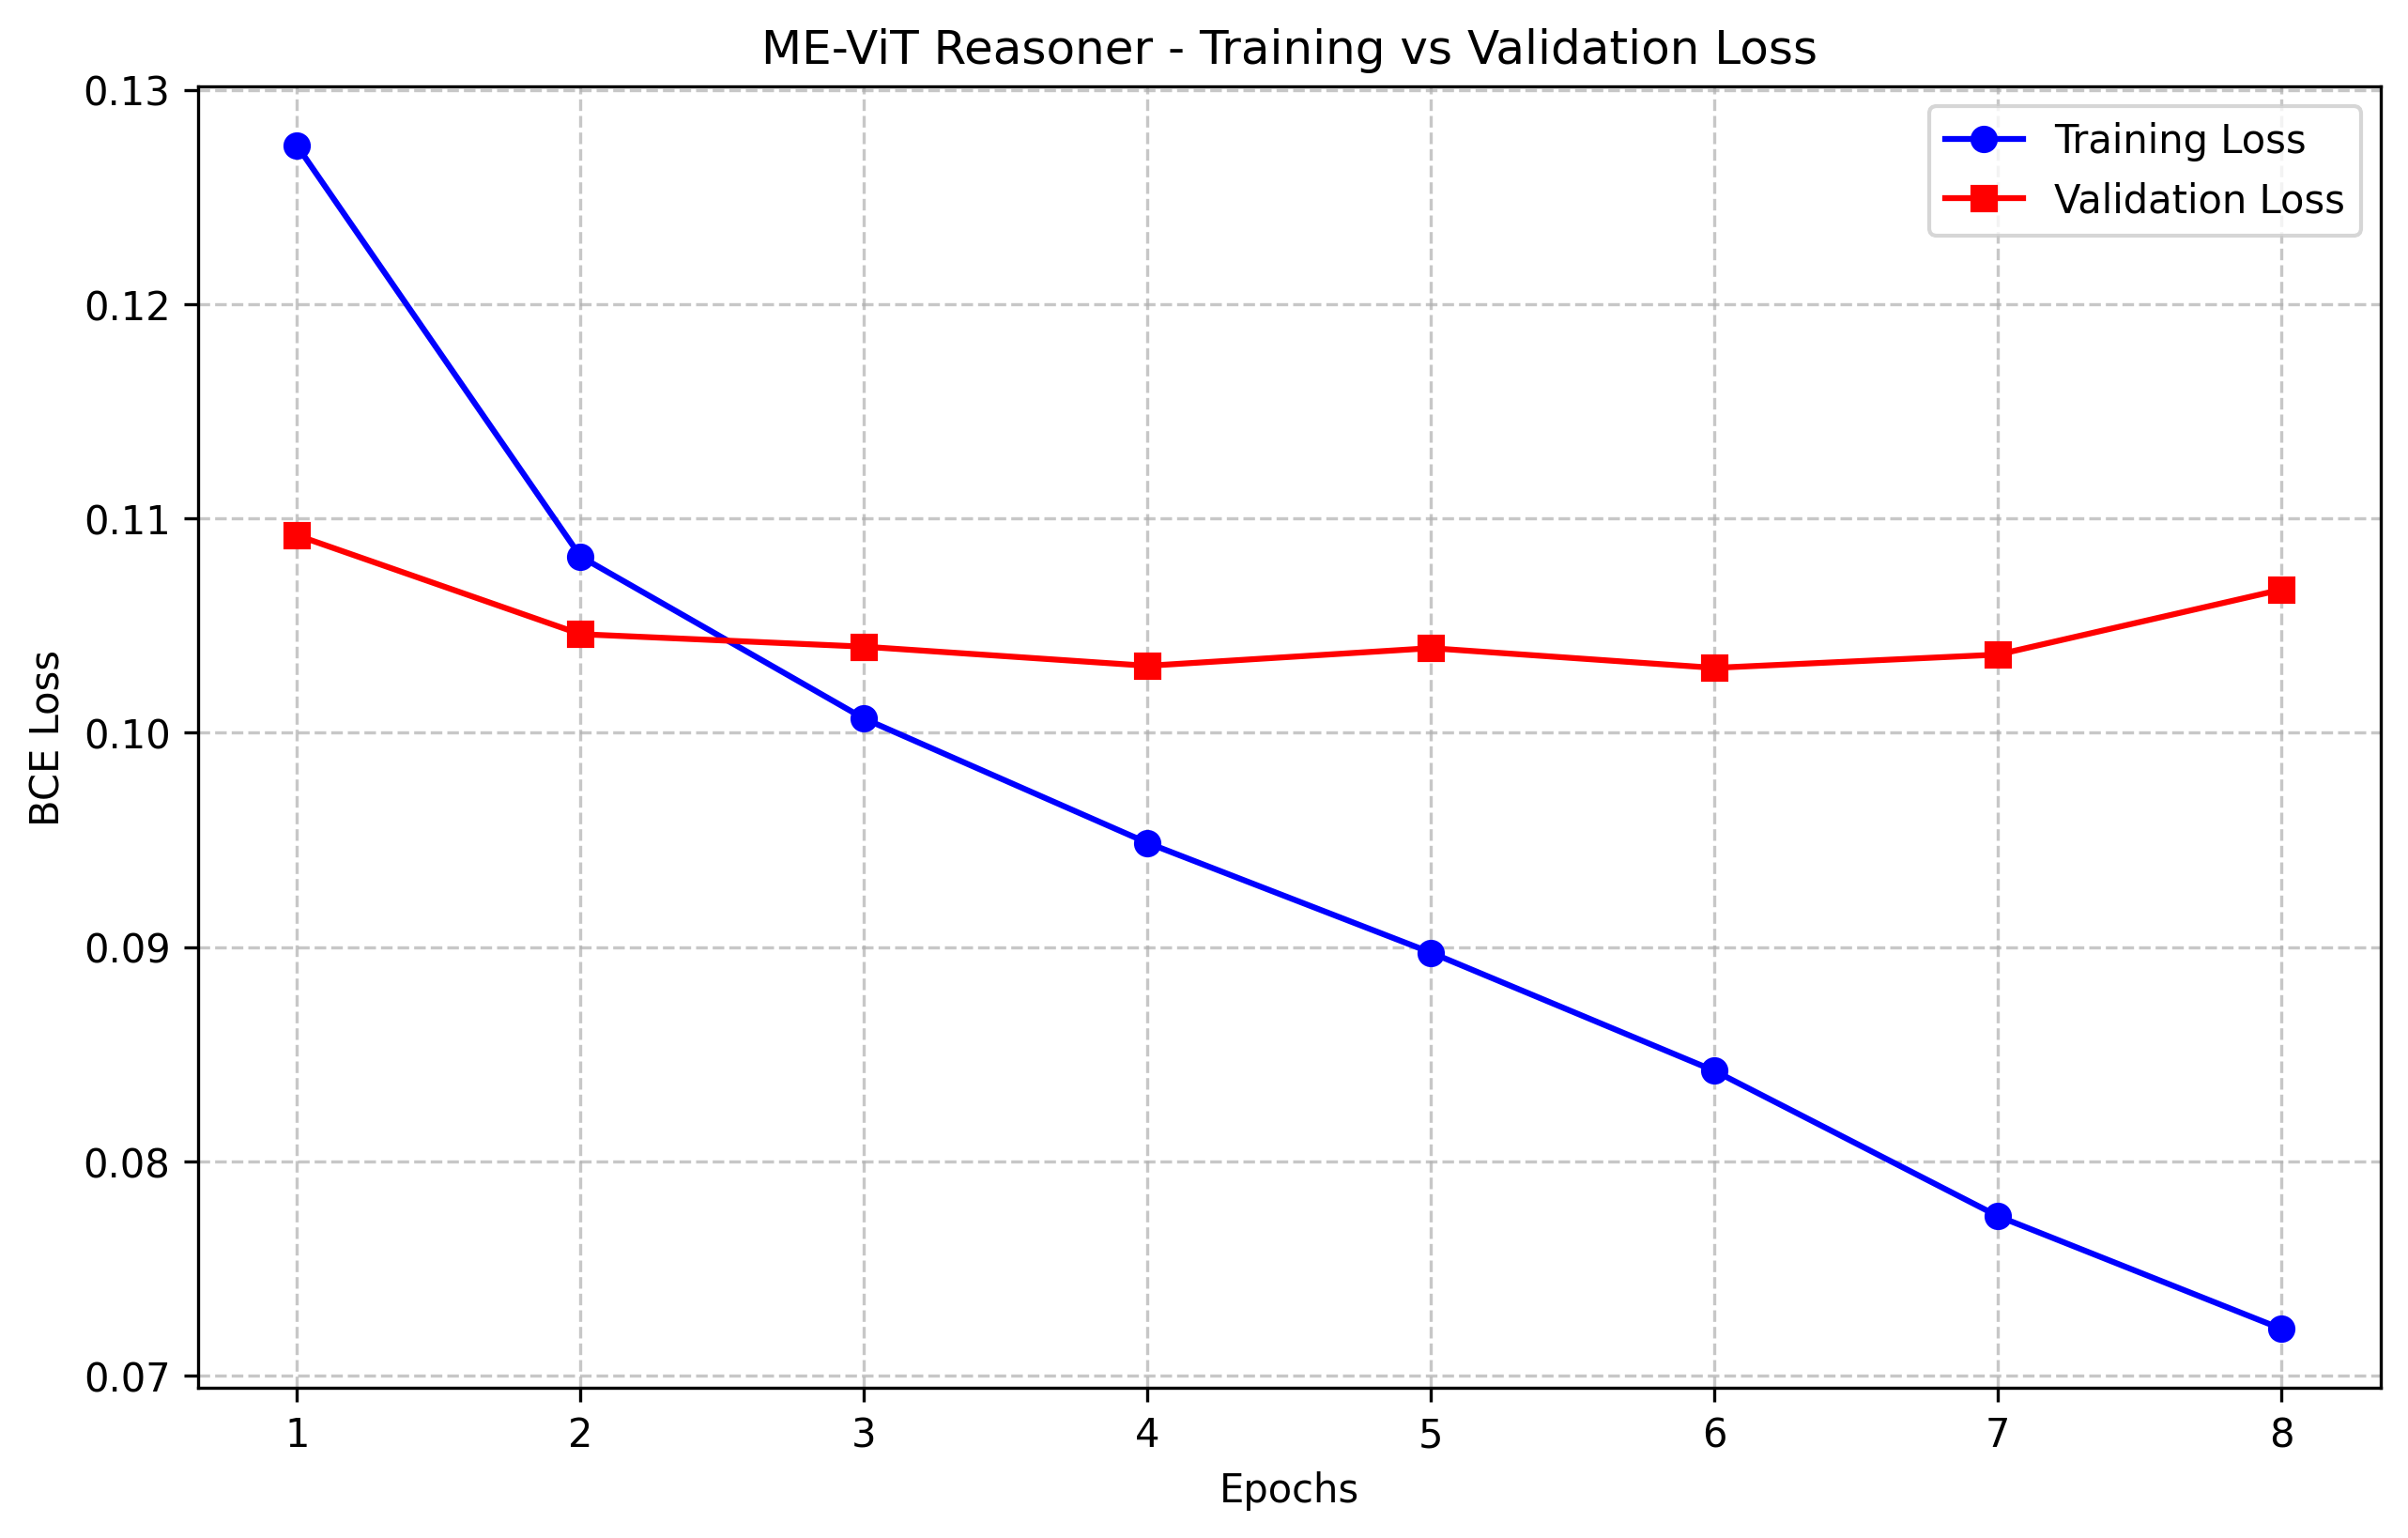

In [ ]:
from utils.plot_metrics import plot_training_losses
from IPython.display import display, Image

plot_path = plot_training_losses(train_history, val_history, save_dir=WEIGHTS_DIR)
display(Image(filename=plot_path))

## 6. Evaluation: Top-1 Task-Aware Accuracy
Runs YOLO inference + ME-ViT relevance fusion over the full test set and computes per-task accuracy.

In [37]:
from utils.evaluate import evaluate_best_model

# Note: evaluate.py uses the frozen ultralytics YOLO for box proposals.
# The ME-ViT weights loaded here are the END-TO-END trained weights.
results = evaluate_best_model(
    data_root    = DATA_ROOT,
    weights_path = ckpt_path,
    output_dir   = WEIGHTS_DIR,
    device       = device
)

Loading Models...
Loading Test Dataset...
Loaded 12600 PREPROCESSED samples for test split.


Evaluating: 100%|██████████| 12600/12600 [07:03<00:00, 29.76it/s]



  SATAY-ViT EVALUATION RESULTS
  Total test samples evaluated    : 6,173
  Top-1 Task-Aware Acc (SATAY-ViT): 50.19%
  Top-1 Confidence Acc (YOLO-only): 15.58%
  Delta (SATAY-ViT - YOLO-only)   : +34.60%
  mAP@0.5 (SATAY-ViT)             : 76.77%
  Precision@0.5                   : 50.19%
------------------------------------------------------------
  Task                 N    SATAY%     YOLO%     Delta
------------------------------------------------------------
  Step on something   486    49.38%    16.67%   +32.72%
  Sit comfortably    660    52.12%    23.48%   +28.64%
  Place flowers      411    55.23%    24.82%   +30.41%
  Get potatoes out of fire   639    51.49%    11.42%   +40.06%
  Water plant        455    56.92%    25.05%   +31.87%
  Get lemon out of tea   438    36.99%     9.82%   +27.17%
  Dig hole           640    57.50%     7.50%   +50.00%
  Open bottle of beer   153    33.99%    18.95%   +15.03%
  Open parcel        207    34.30%     8.70%   +25.60%
  Serve wine         3